# 04 - Gözetimli Makine Öğrenmesi
## Uydu Telemetri Anomali Tespiti

Segment bazlı özellik matrisini kullanarak gözetimli anomali tespiti modellerini eğitmek.

### Modeller:
1. Random Forest
2. Support Vector Machine
3. XGBoost
4. MLP


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings, os, sys
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-darkgrid')

sys.path.insert(0, '..')
sys.path.insert(0, os.path.join('..', 'src'))
from src.models.supervised import SupervisedAnomalyDetector
from metrics import compute_metrics, metrics_table, BENCHMARK_METRICS

print('Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.')

I0000 00:00:1781296454.685148   24159 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1781296455.002462   24159 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


I0000 00:00:1781296456.142346   24159 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


please install torch first
please install torch first
please install torch first
Kütüphaneler, Model Sınıfı ve metrik modülü yüklendi.


---
## Bölüm 1: Veri Hazırlama


In [2]:
# NB02 (ön işleme) çıktılarını yükle — resmi split, RobustScaler ölçekleme ve SMOTE
# orada (leakage-free) yapıldı; burada TEKRAR EDİLMEZ. Tek ön işleme kaynağı: NB02.
PROC = '../data/processed'
_Xtr = pd.read_parquet(f'{PROC}/X_train.parquet')   # RobustScaler + SMOTE'lu T eğitim
feature_cols = list(_Xtr.columns)
X_train_s = _Xtr.values
X_val_s  = pd.read_parquet(f'{PROC}/X_val.parquet').values    # RobustScaler + SMOTE'lu T validation
X_test_s = pd.read_parquet(f'{PROC}/X_test.parquet').values   # RobustScaler'lı resmi Ψ test
y_train_sm = pd.read_parquet(f'{PROC}/y_train.parquet')['anomaly']
y_val      = pd.read_parquet(f'{PROC}/y_val.parquet')['anomaly']
y_test     = pd.read_parquet(f'{PROC}/y_test.parquet')['anomaly']

print(f"NB02'den yüklendi — Train (SMOTE'lu T): {X_train_s.shape}, Val: {X_val_s.shape}, "
      f"Test Ψ: {X_test_s.shape}  ({len(feature_cols)} özellik, RobustScaler)")

NB02'den yüklendi — Train (SMOTE'lu T): (2164, 18), Val: (382, 18), Test Ψ: (529, 18)  (18 özellik, RobustScaler)


---
## Bölüm 2: Random Forest ve XGBoost


In [3]:
detector = SupervisedAnomalyDetector(random_state=42)
rf_model = detector.train_random_forest(X_train_s, y_train_sm, tune=False)
xgb_model = detector.train_xgboost(X_train_s, y_train_sm, X_val_s, y_val)


Random Forest eğitiliyor...


XGBoost eğitiliyor...


---
## Bölüm 3: SVM


In [4]:
svm_model = detector.train_svm(X_train_s, y_train_sm, kernel='rbf')


SVM (rbf kernel) eğitiliyor...


---
## Bölüm 4: MLP


MLP eğitiliyor...


Epoch 1/80


W0000 00:00:1781296460.150981   24159 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


 1/68 ━━━━━━━━━━━━━━━━━━━━ 57s 858ms/step - accuracy: 0.4062 - loss: 0.8289

21/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6012 - loss: 0.6651   

...

 1/68 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - accuracy: 0.9688 - loss: 0.1108

24/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9367 - loss: 0.1460 

45/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9330 - loss: 0.1522

63/68 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9320 - loss: 0.1543

68/68 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9321 - loss: 0.1603 - val_accuracy: 0.9424 - val_loss: 0.1257


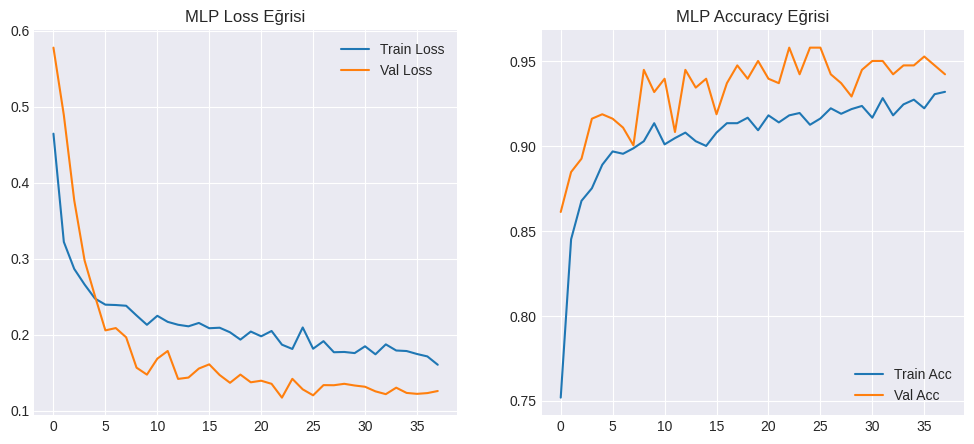

In [5]:
mlp_model, history = detector.train_mlp(X_train_s, y_train_sm.values, X_val_s, y_val.values, epochs=80, batch_size=32)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss'); plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('MLP Loss Eğrisi'); plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc'); plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('MLP Accuracy Eğrisi'); plt.legend()
plt.show()


---
## Bölüm 5: Değerlendirme


In [6]:
demo_metrics = {}
for name in ['RandomForest', 'XGBoost', 'SVM', 'MLP']:
    model = detector.models[name]
    if name == 'MLP':
        prob = model.predict(X_test_s, verbose=0).flatten()
    elif hasattr(model, 'predict_proba'):
        prob = model.predict_proba(X_test_s)[:, 1]
    else:
        prob = model.decision_function(X_test_s)
    pred = (prob >= 0.5).astype(int)
    demo_metrics[name] = compute_metrics(y_test.values, pred, prob)

results_df = metrics_table(demo_metrics, sort_by='AUC_PR')
print("Temsili gözetimli modeller — resmi Ψ (529 segment), AUC_PR sıralı:")
display(results_df[BENCHMARK_METRICS].style.background_gradient(cmap='Blues').format('{:.4f}'))

Temsili gözetimli modeller — resmi Ψ (529 segment), AUC_PR sıralı:


,Accuracy,Precision,Recall,F1,MCC,AUC_ROC,AUC_PR
XGBoost,0.9565,0.9167,0.8761,0.8959,0.8688,0.9742,0.9450
RandomForest,0.9565,0.9245,0.8673,0.8950,0.8683,0.9655,0.9371
MLP,0.9055,0.7143,0.9292,0.8077,0.7578,0.9610,0.9112
SVM,0.8866,0.6906,0.8496,0.7619,0.6949,0.9563,0.8936


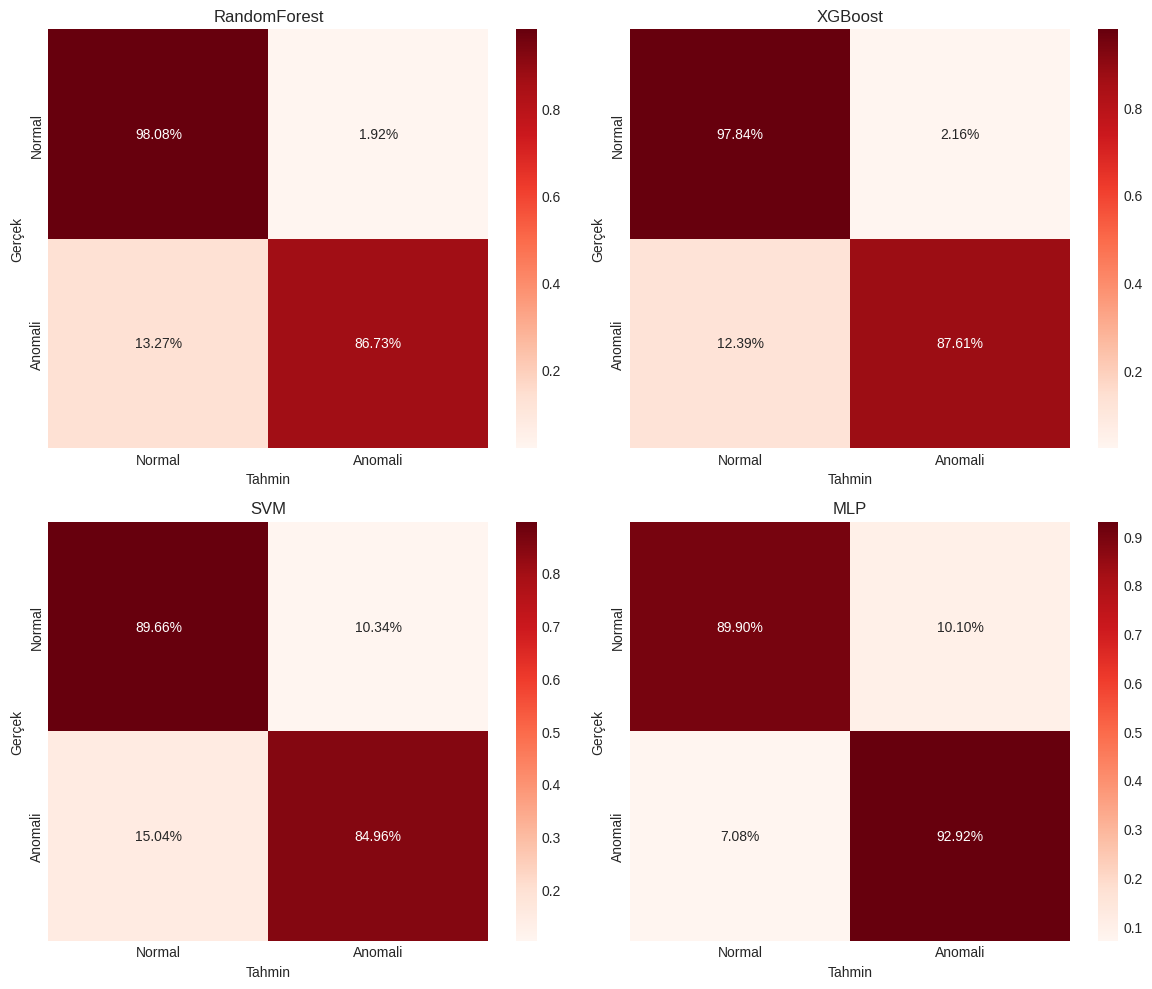

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10)); axes = axes.flatten()
for i, name in enumerate(detector.models.keys()):
    m = detector.models[name]
    yp = (m.predict(X_test_s, verbose=0)>=0.5).astype(int).flatten() if name=='MLP' else m.predict(X_test_s)
    cm = confusion_matrix(y_test, yp, normalize='true')
    sns.heatmap(cm, annot=True, fmt='.2%', cmap='Reds', ax=axes[i], xticklabels=['Normal','Anomali'], yticklabels=['Normal','Anomali'])
    axes[i].set_title(name); axes[i].set_xlabel('Tahmin'); axes[i].set_ylabel('Gerçek')
plt.tight_layout(); plt.show()


---
## Bölüm 6: ROC Eğrisi


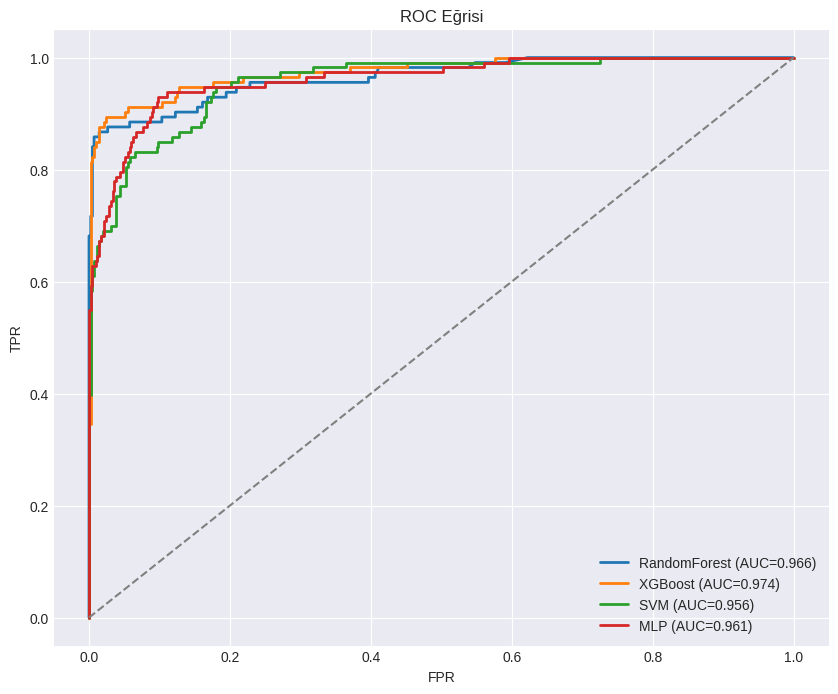

In [8]:
plt.figure(figsize=(10, 8))
for name, model in detector.models.items():
    yp = model.predict(X_test_s, verbose=0).flatten() if name=='MLP' else (model.predict_proba(X_test_s)[:,1] if hasattr(model,'predict_proba') else model.decision_function(X_test_s))
    fpr,tpr,_ = roc_curve(y_test, yp); ra = auc(fpr,tpr)
    plt.plot(fpr, tpr, lw=2, label=f'{name} (AUC={ra:.3f})')
plt.plot([0,1],[0,1],color='gray',linestyle='--')
plt.xlabel('FPR'); plt.ylabel('TPR'); plt.title('ROC Eğrisi'); plt.legend(loc='lower right')
plt.show()


---
## Bölüm 7: Kaydetme ve Kanonik Model Havuzu

Bu notebook'ta Random Forest, XGBoost, SVM ve MLP gösterim amacıyla ayrıntılı ele
alınmıştır. Bunların yanında gözetimli model havuzunun tamamı `train_all_models.py`
ile resmi split üzerinde eğitilir ve sonuçları NB06'da (`final_comparison.json`)
karşılaştırılır:

- Klasik ML ve topluluk: Extra Trees, Gradient Boosting, HistGradientBoosting,
  AdaBoost, Bagging, KNN, Logistic Regression, Decision Tree, Naive Bayes, LDA, QDA,
  Ridge, SGD, Voting, Stacking, LightGBM, CatBoost, XGBOD.
- Derin sıralı ve hibrit ağlar: LSTM, BiLSTM, GRU, BiGRU, 1D-CNN, CNN-LSTM,
  CNN-BiLSTM, CNN-GRU, Transformer, TCN, Attention-BiLSTM, FCN, ResNet-1D,
  InceptionTime, LSTM-FCN.

In [9]:
print("Bu notebook gösterim amaçlıdır; gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir, sonuçlar NB06'da.")

Bu notebook gösterim amaçlıdır; gözetimli model havuzunun tamamı train_all_models.py'de kanonik eğitilir, sonuçlar NB06'da.
